In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("/Users/vinodbadesha/Desktop/uber_rides_analysis/rideBookings.csv")
df = pd.DataFrame(data)

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


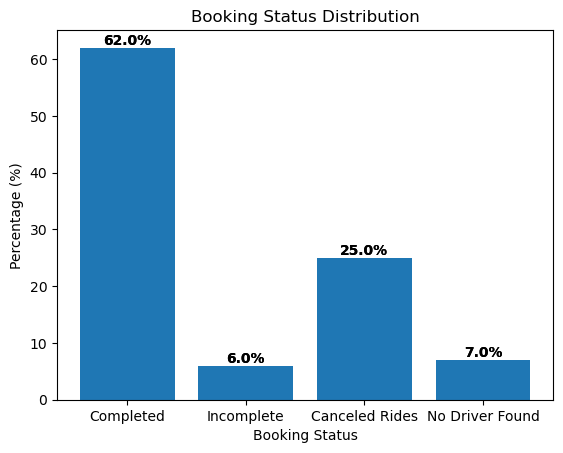

In [33]:
total_rides = len(df)

completed_rides_percent = (len(df[df["Booking Status"] == "Completed"]) / total_rides) * 100
completed_rides_percent # 62%

incomplete_rides_percent = (len(df[df["Booking Status"] == "Incomplete"]) / total_rides) * 100
incomplete_rides_percent # 6%

canceled_by_customer = len(df[df["Booking Status"] == "Cancelled by Customer"])
canceled_by_driver = len(df[df["Booking Status"] == "Cancelled by Driver"])
canceled_rides = canceled_by_customer + canceled_by_driver

canceled_rides_percent = (canceled_rides / total_rides) * 100
canceled_rides_percent # 25%

no_driver_found = len(df[df["Booking Status"] == "No Driver Found"])

no_driver_found_percent = (no_driver_found / total_rides) * 100
no_driver_found_percent # 7%

booking_status = ["Completed", "Incomplete", "Canceled Rides", "No Driver Found"]
booking_status_percent = [completed_rides_percent, incomplete_rides_percent, canceled_rides_percent, no_driver_found_percent]

plt.bar(booking_status, booking_status_percent)
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Percentage (%)")

for i,v in enumerate(booking_status_percent):
    plt.text(i, v+0.5, str(round(v, 2)) + "%", ha="center", fontweight="bold")


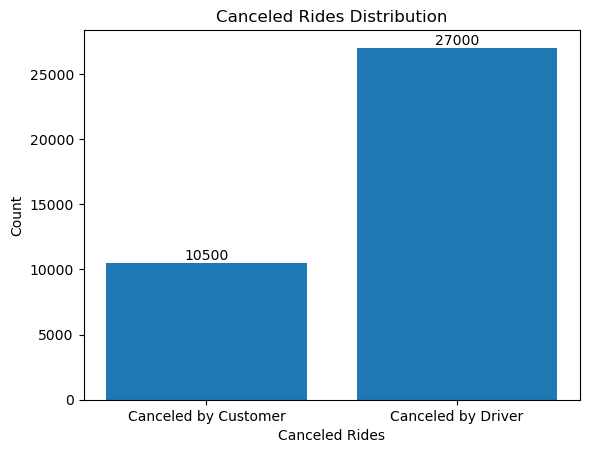

In [93]:
### Canceled Rides Distribution

canceled = ["Canceled by Customer", "Canceled by Driver"]
canceled_rides_count = [canceled_by_customer, canceled_by_driver]

plt.bar(canceled, canceled_rides_count)
plt.title("Canceled Rides Distribution")
plt.xlabel("Canceled Rides")
plt.ylabel("Count")

for i,v in enumerate(canceled_rides_count):
    plt.text(i, v+200, str(v), ha="center")

# The cancellations by drivers are 2.5 times more than that of the customers.
# It is clearly the problem of the company.

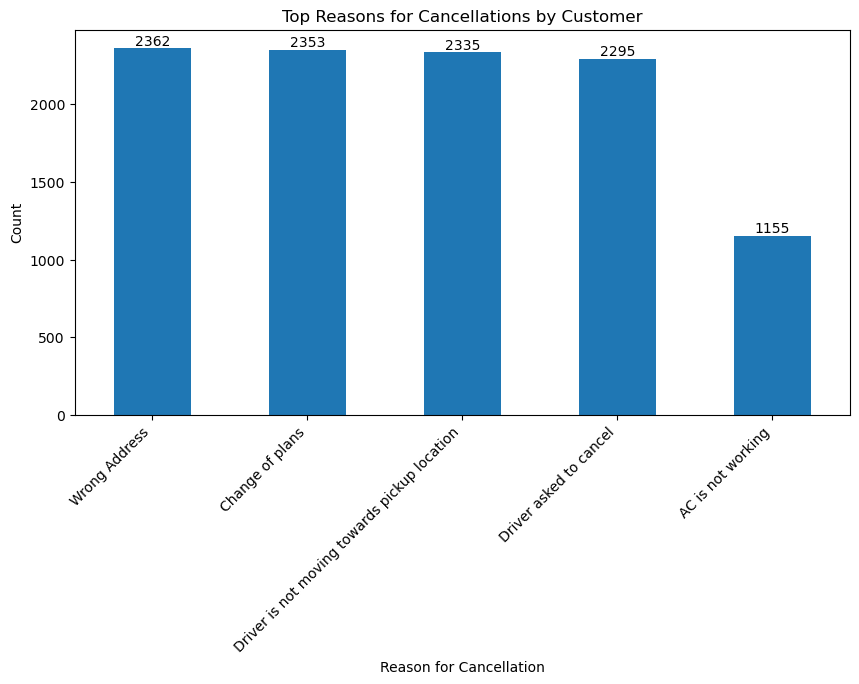

In [92]:
### Top Reasons for Cancellations by Customers

customer_reasons_count = df["Reason for cancelling by Customer"].value_counts()
customer_reasons_count.plot(kind="bar", title="Top Reasons for Cancellations by Customer", xlabel="Reason for Cancellation", ylabel="Count")
plt.xticks(rotation=45, ha="right")

for i,v in enumerate(customer_reasons_count):
    plt.text(i, v+20, str(v), ha="center")

# Top 4 reasons are equallu distributed among drivers and customers.
# Driver asking to cancel can imply that the customers being pressurised by the drivers to cancel the ride.
# AC not working shows comfort is a factor.


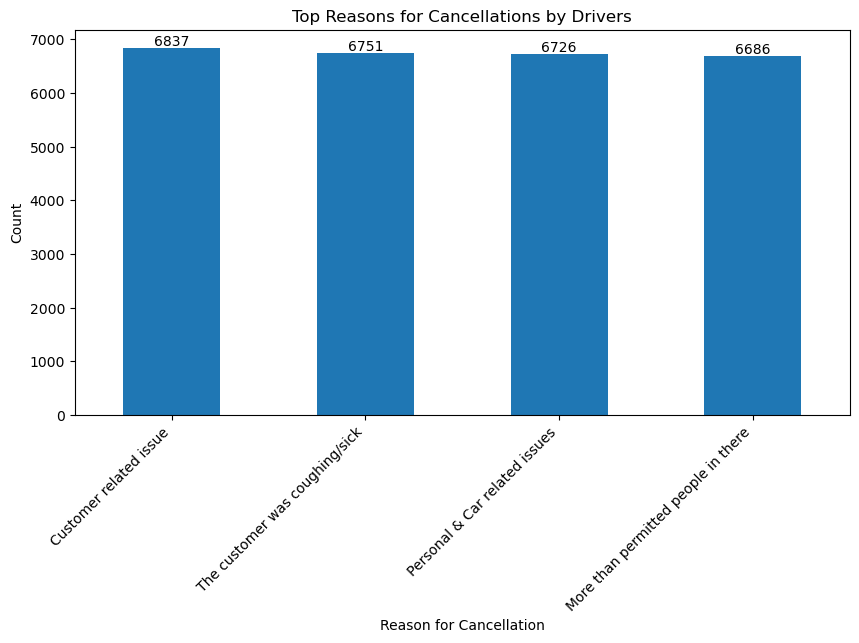

In [89]:
### Top Reasons for Cancellations by Drivers

driver_cancellation_reasons = df["Driver Cancellation Reason"].value_counts()
plt.figure(figsize=(10,5))
driver_cancellation_reasons.plot(kind="bar", title="Top Reasons for Cancellations by Drivers", xlabel="Reason for Cancellation", ylabel="Count")
plt.xticks(rotation=45, ha="right")

for i,v in enumerate(driver_cancellation_reasons):
    plt.text(i, v+50, str(v), ha="center")

# The reasons are evenly distributed
# The customer related issue as the top reasons looks vague, as a generic excuse.
# The customer is was coughing/sick and more people than permitted looks like a legit issue. 

In [94]:
### KEY INSIGHT

# Driver-side cancellations are 2.5 times more than that if the customers. Uber needs strict cancellation policies and better incentives to reduce this gap.

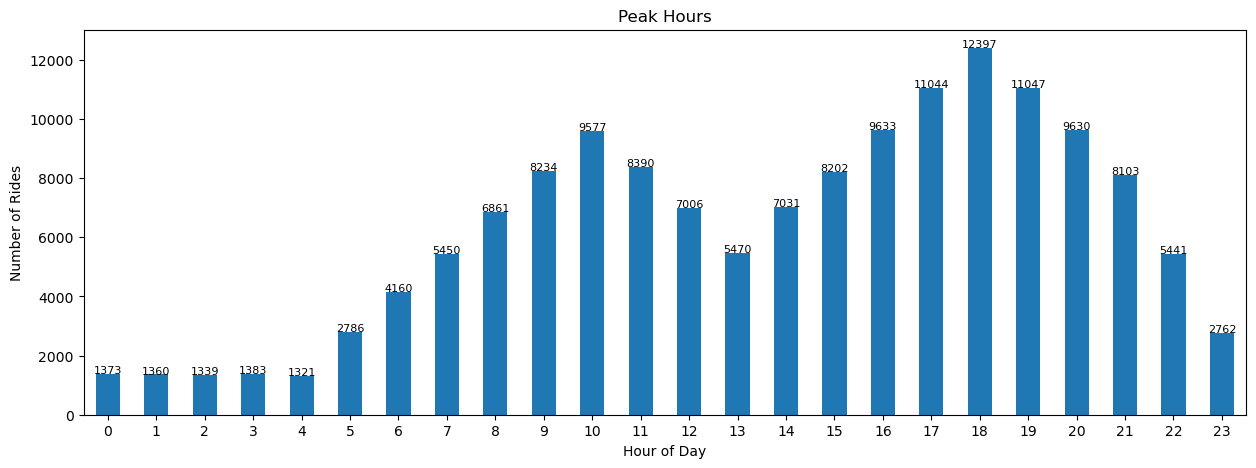

In [132]:
### PEAK HOURS

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour
peak_hours = df["Hour"].value_counts().sort_index()
plt.figure(figsize=(15,5))

peak_hours.plot(kind="bar", title="Peak Hours", xlabel="Hour of Day", ylabel="Number of Rides")
plt.xticks(rotation=0)
for i,v in enumerate(peak_hours):
    plt.text(i, v+20, str(v), ha="center", fontsize=8)


# Peak Hours of business are between 17-19 hours, which is the evening time, 
# in which highest number of rides were recorded at 18th hour with 12,397 rides.
# Least business hours are between 0-4 hours (midnight to early morning), with an average of ~1300 rides per hour.
# Uber should focus on increasing driver availability during peak hours and consider surge pricing during these hours.



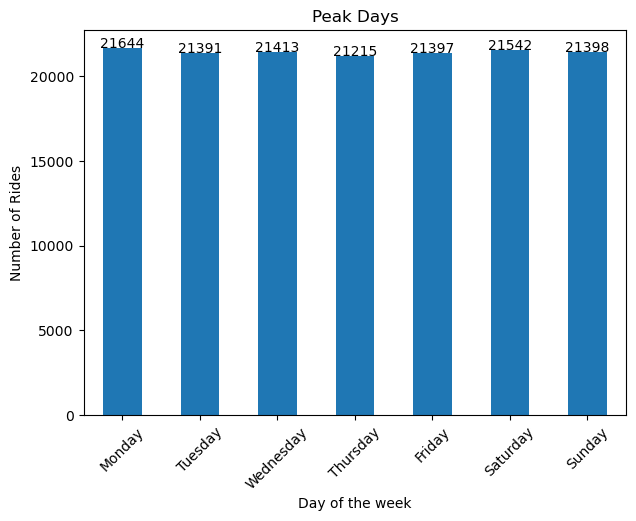

In [133]:
### PEAK DAYS
df["Date"] = pd.to_datetime(df["Date"])
df["Day"] = df["Date"].dt.day_name()

peak_days = df["Day"].value_counts().sort_index()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
peak_days = peak_days.reindex(day_order)
plt.figure(figsize=(7,5))
peak_days.plot(kind="bar", title="Peak Days", xlabel="Day of the week", ylabel="Number of Rides")
plt.xticks(rotation=45)
for i,v in enumerate(peak_days):
    plt.text(i, v+20, str(v), ha="center")

###
# Bookings are consistent across all days of the week, ranging from 21,215 on Thursday to 21,644 on Monday.
# Unlike other transport services that see the spike on weekends, Uber rides rides show no significant weekday vs weekend pattern.


<Axes: title={'center': 'Vehicle Type Preferred'}>

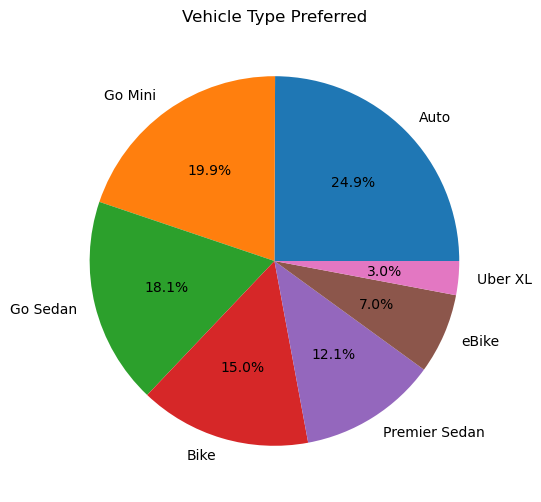

In [142]:
### VEHICLE TYPE PREFERENCE

vehicle_type = df["Vehicle Type"].value_counts()
plt.figure(figsize=(6,6))
vehicle_type.plot(kind="pie", title="Vehicle Type Preferred", autopct="%1.1f%%", ylabel="")

###
# Auto is the most preferred vehicle over other categories at 24.9% of the total bookings. followed by Go Mini at 19.9%. 
# Uber XL sitting at the least 3% implies that large-capacity vehicles are least preferred.
# Uber should maintain a higher fleet ratio of Autos and reduce Uber Xl available in low-demand areas to optimize driver utilzation

<Axes: title={'center': 'Payment Methods'}>

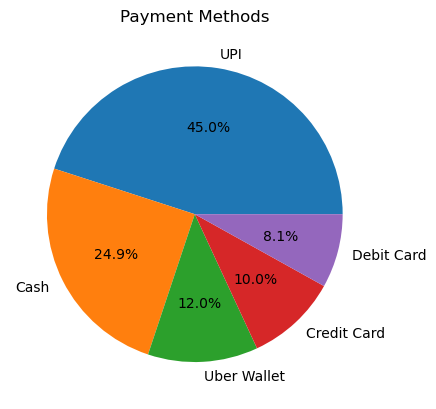

In [145]:
payment_modes = df["Payment Method"].value_counts()
payment_modes.plot(kind="pie", title="Payment Methods", autopct="%1.1f%%", ylabel="")

###
# UPI dominates with a 45%, while cash payments are 24.9%.
# Debit card(8.1%), credit card(10%), and uber wallet(12%) makes up to ~30% only.
# 

In [167]:
avg_customer_ratings = round(float(df["Customer Rating"].mean()), 2) #4.4
avg_driver_ratings = round(float(df["Driver Ratings"].mean()), 2) # 4.23

top_customer_ratings = df[df["Customer Rating"] == 5].shape[0]
top_customer_ratings

normal_customer_ratings = df[df["Customer Rating"] < 5].shape[0]
normal_customer_ratings, top_customer_ratings

top_driver_ratings = df[df["Driver Ratings"] == 5].shape[0]
top_driver_ratings

normal_driver_ratings = df[df["Driver Ratings"] < 5].shape[0]
normal_driver_ratings, top_driver_ratings

###
# Average driver rating by customers is 4.4 and average customer ratings by drivers is 4.23%.
# customers rated drivers higher than drivers rated customers.
# only 2365 rides have got 5-star rating, i.e., 2.5% of completed rides.
# while 5837 rides were been rated with 5-stars, i.e., 6.3% of the completed rides.


(90635, 2365)

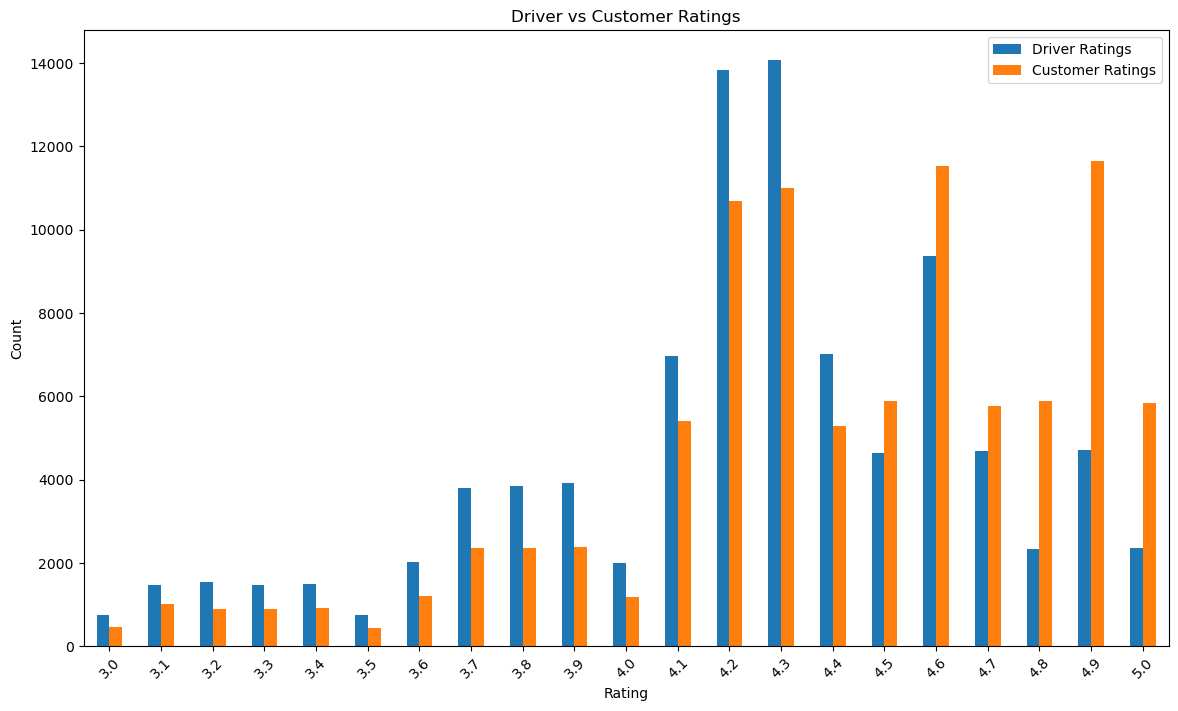

In [192]:
driver_ratings_counts = df["Driver Ratings"].value_counts().sort_index()
customer_ratings_counts = df["Customer Rating"].value_counts().sort_index()

ratings_df = pd.DataFrame({
    "Driver Ratings": driver_ratings_counts,
    "Customer Ratings": customer_ratings_counts
})

ratings_df.plot(kind="bar", title="Driver vs Customer Ratings", ylabel="Count", xlabel="Rating", figsize=(14,8))
plt.xticks(rotation=45);

###
# drivers ratings that are ratings by the customer to the driver, clusters between 4.2-4.3, showing that customers are moderately satisfied by the driver.
# customer ratings that are ratings by the driver to the customer, skew higher toward 4.6-4.9, indicating that drivers rate customers more generously than the customers.
# avg. driver rating = 4.23 and avg. customer rating = 4.4
# the company should focus more on improving driver quality to push up the ratings above 4.5

In [ ]:
correlation = df['Ride Distance'].corr(df['Booking Value'])
round(float(correlation), 2)

# the overall correlation between Ride Distance and Booking Value is 0.01.
# There is no relationship between both the parameters.
# generally, the booking value must scale up with the ride distance. but it is not the case.
# The vehicle type or price surging must be influencing the booking value rather than ride distance itself


0.01

In [ ]:
df.groupby('Vehicle Type')[['Ride Distance', 'Booking Value']].corr().iloc[0::2, -1]

# Correlation as per vehicle type - (-0.02 to 0.1).
# The correlation still seems to show no relationship between Ride Distance and Booking Value across all types.
# It indicates that the vehicle type is not influencing the booking value.
# Booking value include incomplete rides that has a booking value. they might be a cause for low correlation.
# pricing model is relying heavily on peak hours, surge pricing and zone based fares.

Vehicle Type                
Auto           Ride Distance    0.007202
Bike           Ride Distance    0.005848
Go Mini        Ride Distance    0.003293
Go Sedan       Ride Distance    0.004885
Premier Sedan  Ride Distance    0.007609
Uber XL        Ride Distance   -0.023965
eBike          Ride Distance    0.010802
Name: Booking Value, dtype: float64

In [ ]:
df[df["Incomplete Rides"] != 1.0].groupby('Vehicle Type')[['Ride Distance', 'Booking Value']].corr().iloc[0::2, -1]

# the correlation is still (-0.03 to 0.01)
# the booking value has no relationship with the ride distance.
# it is the Uber's fare structure that is not relying primarily on ride distance.
# likely driven by price surging, time-based and zone-based fares.


Vehicle Type                
Auto           Ride Distance    0.008701
Bike           Ride Distance    0.010696
Go Mini        Ride Distance    0.004453
Go Sedan       Ride Distance    0.001123
Premier Sedan  Ride Distance    0.007121
Uber XL        Ride Distance   -0.032628
eBike          Ride Distance    0.012928
Name: Booking Value, dtype: float64

In [231]:
### KEY INSIGHTS

# Uber 2024 Rides Data - The dataset is the collection of rides that were booked in 2024. It include both complete, and incomplete rides.

# 1. Ride Completion - Only 62% of booked rides were completed and 7% rides were failed due to "No Driver Found". 25% were canceled, 
# with driver-side cancellations having 2.5x more than customer-side cancellations. Rest 6% remaind incomplete.

# 2. Cancellation Behavior - Drivers often canceled more rides than the customers (27,000 vs 10,500). The customer reasons were spread evenly, 
# like wrong address, driver unresponsive, and change of plans while the driver reasons were vague ("Customer related issue" tops the list).

# 3. Demand Patterns - Bookings were peak during evening hours between 17:00-19:00 with 18th hour alone recording 12,397 rides.
# Demand was uniform across all 7 days of the week without weekday vs weekend apikes.

# 4. Vehicle Preference - Dominated by budget options like Auto(24.9%), Go Mini(19.9%), Go Sedan(18.1%), making upto ~63% of total bookings. 
# Premium options just account to ~3%

# 5. Payment Modes - UPI is dominant with 45% followed by cash payments with 24.9% - together nearly 70% of the transactions.

# 6. Ratings Distribution - Customers rate drivers highly with average ratings of 4.4 than drivers rate customers (4.23), 
# suggesting drivers may face friction points during rides.

# 7. Price Structure - Booking value shows no correlation with Ride distance - 0.01, even after verifying on vehicle type and incomplete rides.
# It looks like Uber's fare structure is primarily relying on zone, time, and surge price factors rather than distance travelled. 


# RECOMMENDATIONS
# 1. Improve driver availability during 17:00-19:00 to address peak hour gaps, and consider incentives during those hours.
# 2. Cash dependency must be reduced by promoting cashback offers in UPI or drivers must be asked to maintain a minimum denomination 
# of cash to avoid any inconsistencies.
# 3. Company must go audit the fare calculation model as distance did not found to be the primary pricing driver, which may indicate 
# inconsistency or opportunity for a more transparent pricing structure.
# 4. Maintain strong Auto/ Go Sedan/ Go Mini fleet supply given consistently high demand for budget vehicle types.